In [2]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [3]:
class MyNerualNet(nn.Module):
    def __init__(self, layers, size_list):
        super().__init__()
        self.input_size, self.hidden_size, self.output_size = size_list

        self.layers = nn.ModuleList()
        
        self.layers.append(nn.Linear(self.input_size, self.hidden_size))
        self.out = nn.Linear(self.hidden_size, self.output_size)

        for _ in range(layers - 2):
            self.layers.append(nn.Linear(self.hidden_size, self.hidden_size))
        
        # self.fc1 = nn.Linear(2, 16)
        # self.fc2 = nn.Linear(16, 16)
        # self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))
        return self.out(x)
        
    #     x = torch.relu(self.fc1(x))
    #     x = torch.relu(self.fc2(x))
    #     x = self.fc3(x)
    #     return x

In [4]:
def make_spirals(n_samples=300, noise=0.1, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
        
    n = n_samples // 2
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi
    
    r_a = 2 * theta + np.pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    data_a += np.random.randn(n, 2) * noise
    
    r_b = -2 * theta - np.pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    data_b += np.random.randn(n, 2) * noise
    
    X = np.vstack([data_a, data_b])
    y = np.zeros(n_samples, dtype=int)
    y[n:] = 1
    
    return X, y


In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

X, y = make_spirals(n_samples=5000, noise=0.2, random_state=42)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(train_dataset, batch_size=32)

In [8]:
model = MyNerualNet(10,[2,16,1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 100

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() 
    train_loss /= len(train_loader)
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {train_loss:.4f}")
    
print("Final Loss:", train_loss)

Epoch 0, Loss: 0.4037
Epoch 50, Loss: 0.0000
Final Loss: 3.353241274872687e-09


In [9]:
# model.eval()
test_loss = 0
# with torch.no_grad():
for batch_X, batch_y in test_loader:
    outputs = model(batch_X)
    loss = criterion(outputs, batch_y)
    loss.backward()
    test_loss += loss.item()
test_loss /= len(test_loader)
print(f"Train Loss={train_loss:.4f},\nTest Loss={test_loss:.4f}")

Train Loss=0.0000,
Test Loss=0.0000


In [10]:
def evaluate(loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

print("Train Acc:", evaluate(train_loader) * 100)
print("Val Acc:", evaluate(test_loader) * 100)

Train Acc: 100.0
Val Acc: 100.0


In [11]:
def plot_decision_boundary(model, X, y):
    model.eval()
    
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits)
    
    Z = probs.reshape(xx.shape).numpy()
    
    plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap="coolwarm", edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

In [12]:
def plot_3d_surface(model, X, y):
    model.eval()

    # Create grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # Get predictions
    with torch.no_grad():
        logits = model(grid)
        probs = torch.sigmoid(logits)

    Z = probs.reshape(xx.shape).numpy()

    # Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(xx, yy, Z, alpha=0.6)
    
    # Scatter original points
    ax.scatter(
        X[:, 0], X[:, 1], y.squeeze(),
        c=y.squeeze(), cmap='coolwarm', edgecolor='k'
    )

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("Probability")
    ax.set_title("3D Decision Surface")

    plt.show()

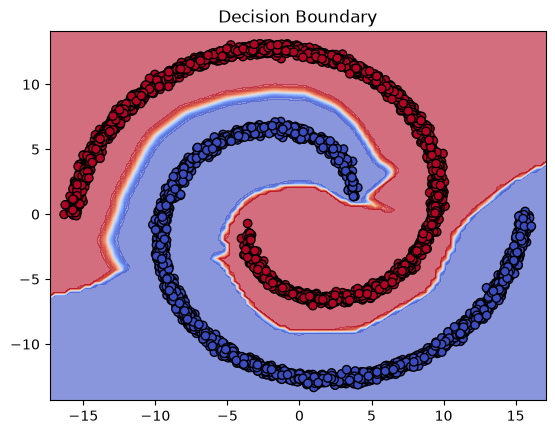

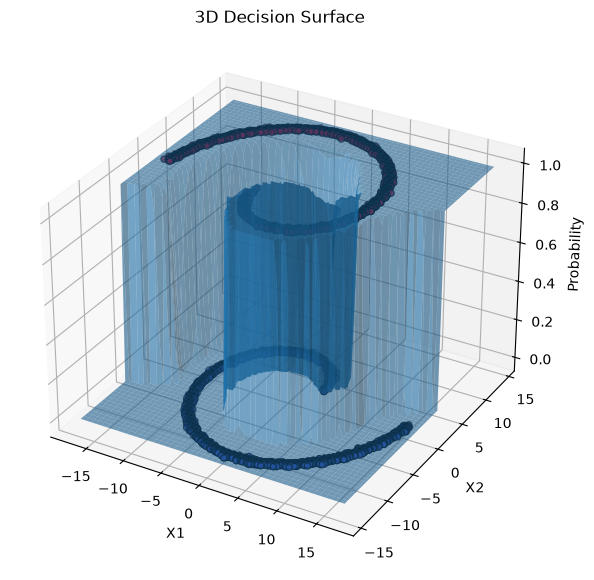

In [13]:
plot_decision_boundary(model, X.numpy(), y.numpy())
plot_3d_surface(model, X.numpy(), y.numpy())